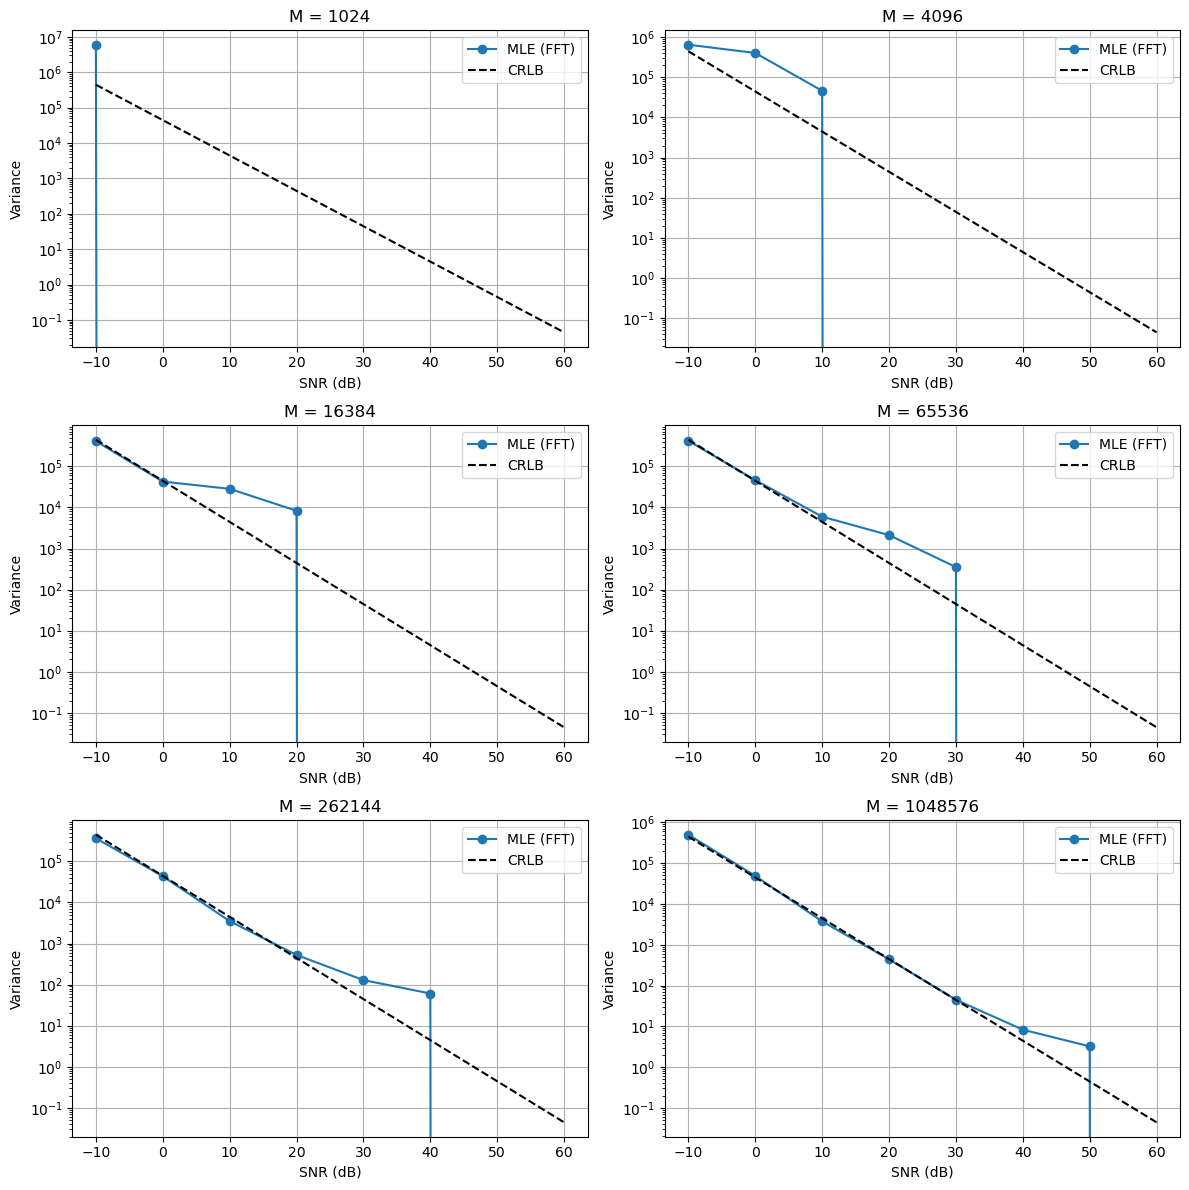

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- SETUP ----------
N = 513
n = np.arange(-256, 257)
T = 1e-6

f0 = 1e5
omega0 = 2 * np.pi * f0

# ---------- SIGNAL ----------
def generate_signal(SNR_dB):
    SNR = 10**(SNR_dB / 10)
    sigma2 = 1 / (2 * SNR)

    noise = (np.random.normal(0, np.sqrt(sigma2), N) +
             1j * np.random.normal(0, np.sqrt(sigma2), N))

    signal = np.exp(1j * (omega0 * n * T))
    return signal + noise

# ---------- FREKVENS ESTIMATOR (MLE-ish FFT) ----------
def estimate_frequency(x, M):
    X = np.fft.fft(x, n=M)
    k_max = np.argmax(np.abs(X))
    return 2 * np.pi * k_max / (M * T)

# ---------- SIM ----------
def simulate_freq(SNR_dB, M, runs=50):
    errors = []

    for _ in range(runs):
        x = generate_signal(SNR_dB)
        omega_hat = estimate_frequency(x, M)
        errors.append(omega0 - omega_hat)

    return np.var(errors)

# ---------- CRLB ----------
def crlb_freq(SNR_dB):
    SNR = 10**(SNR_dB/10)
    sigma2 = 1/(2*SNR)

    var_freq = (12*sigma2)/(T**2 * N * (N**2 - 1))
    return var_freq

# ---------- PARAMETRE ----------
SNR_values = np.arange(-10, 61, 10)
M_values = [2**10, 2**12, 2**14, 2**16, 2**18, 2**20]

# ---------- PLOT ----------
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

# CRLB (samme for alle M)
freq_crlb = [crlb_freq(snr) for snr in SNR_values]

for idx, M in enumerate(M_values):
    freq_variance = []

    for snr in SNR_values:
        v = simulate_freq(snr, M)
        freq_variance.append(v)

    ax = axes[idx]
    
    # MLE
    ax.semilogy(SNR_values, freq_variance, 'o-', label='MLE (FFT)')
    
    # CRLB
    ax.semilogy(SNR_values, freq_crlb, 'k--', label='CRLB')

    ax.set_title(f"M = {M}")
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("Variance")
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.show()

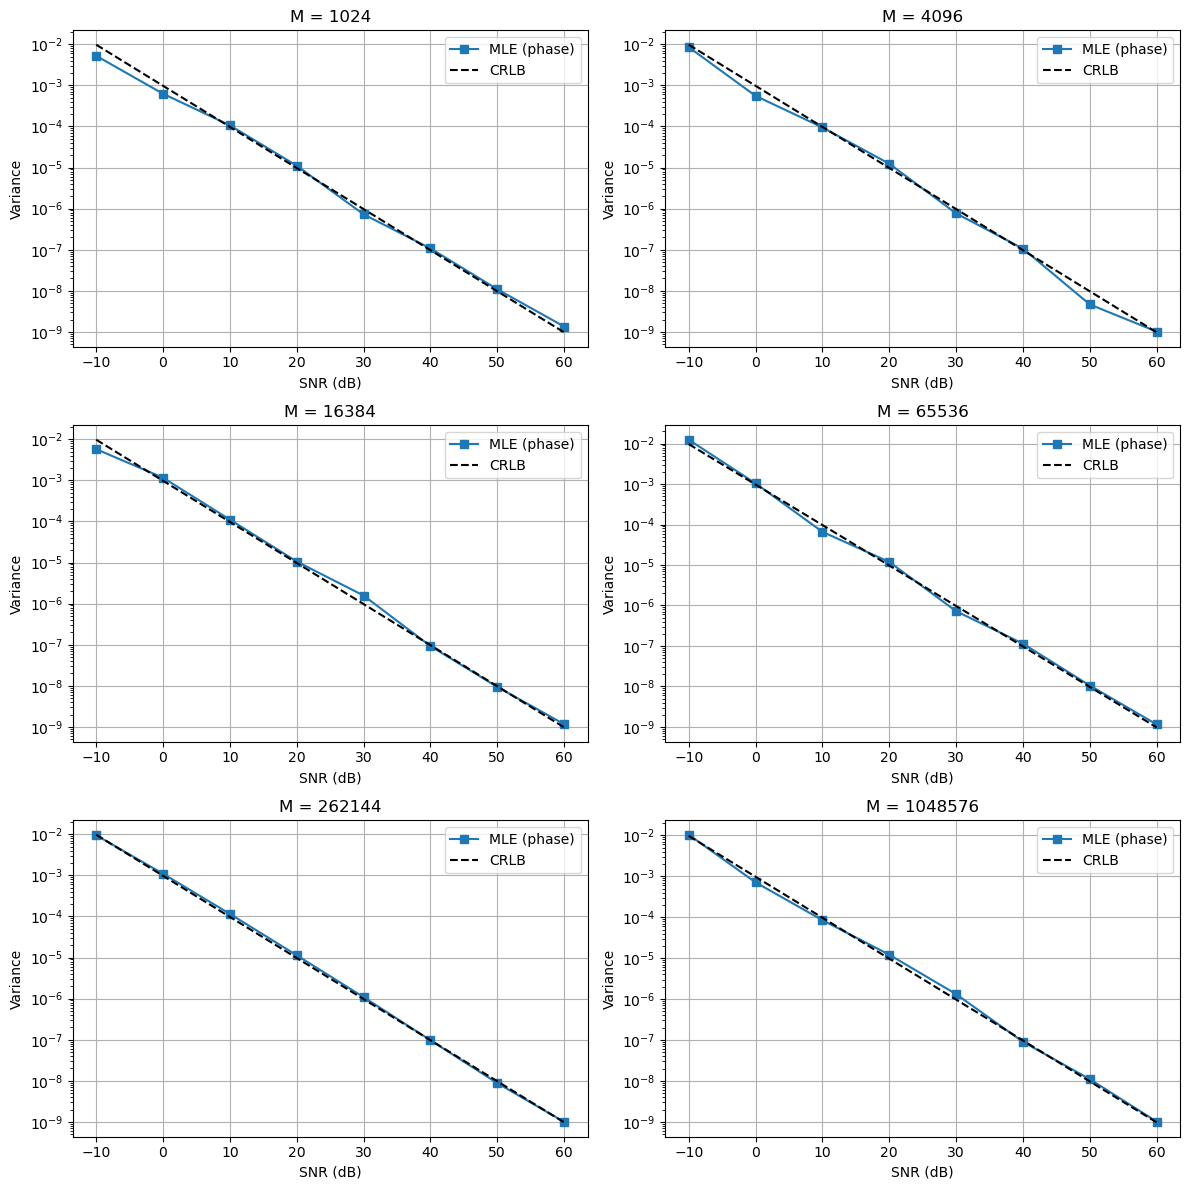

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- SETUP ----------
N = 513
n = np.arange(-256, 257)
T = 1e-6

f0 = 1e5
omega0 = 2 * np.pi * f0
phi_true = np.pi / 8

# ---------- SIGNAL ----------
def generate_signal(SNR_dB):
    SNR = 10**(SNR_dB / 10)
    sigma2 = 1 / (2 * SNR)

    noise = (np.random.normal(0, np.sqrt(sigma2), N) +
             1j * np.random.normal(0, np.sqrt(sigma2), N))

    signal = np.exp(1j * (omega0 * n * T + phi_true))
    return signal + noise

# ---------- FREKVENS ----------
def estimate_frequency(x, M):
    X = np.fft.fft(x, n=M)
    k_max = np.argmax(np.abs(X))
    return 2 * np.pi * k_max / (M * T)

# ---------- FASE ----------
def estimate_phase(x, omega_hat):
    F = np.mean(x * np.exp(-1j * omega_hat * n * T))
    return np.angle(F)

# ---------- SIM ----------
def simulate_phase(SNR_dB, M, runs=50):
    errors = []

    for _ in range(runs):
        x = generate_signal(SNR_dB)

        omega_hat = estimate_frequency(x, M)
        phi_hat = estimate_phase(x, omega_hat)

        errors.append(phi_true - phi_hat)

    return np.var(errors)

# ---------- CRLB ----------
def crlb_phase(SNR_dB):
    SNR = 10**(SNR_dB/10)
    sigma2 = 1/(2*SNR)

    n0 = -256
    P = N*(N-1)/2
    Q = N*(N-1)*(2*N-1)/6

    var_phase = (12*sigma2*(n0**2*N + 2*n0*P + Q)) / (N**2 * (N**2 - 1))
    return var_phase

# ---------- PARAMETRE ----------
SNR_values = np.arange(-10, 61, 10)
M_values = [2**10, 2**12, 2**14, 2**16, 2**18, 2**20]

# ---------- PLOT ----------
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

# CRLB (samme for alle M)
phase_crlb = [crlb_phase(snr) for snr in SNR_values]

for idx, M in enumerate(M_values):
    phase_variance = []

    for snr in SNR_values:
        v = simulate_phase(snr, M)
        phase_variance.append(v)

    ax = axes[idx]
    
    # MLE
    ax.semilogy(SNR_values, phase_variance, 's-', label='MLE (phase)')
    
    # CRLB
    ax.semilogy(SNR_values, phase_crlb, 'k--', label='CRLB')

    ax.set_title(f"M = {M}")
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("Variance")
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.show()

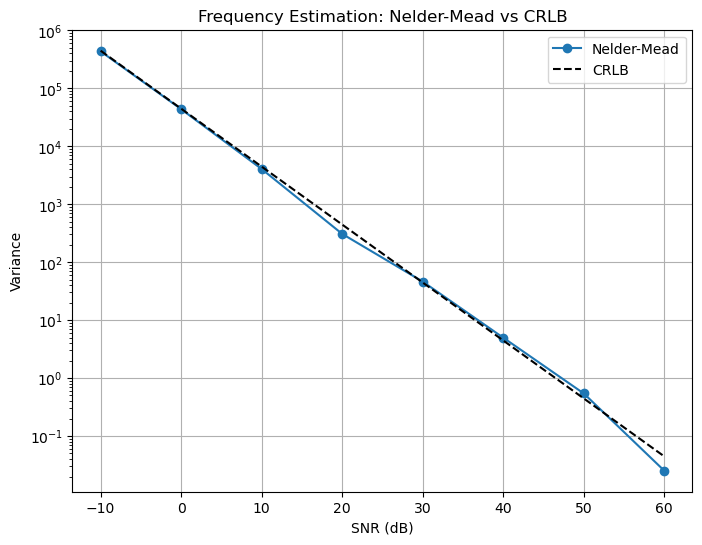

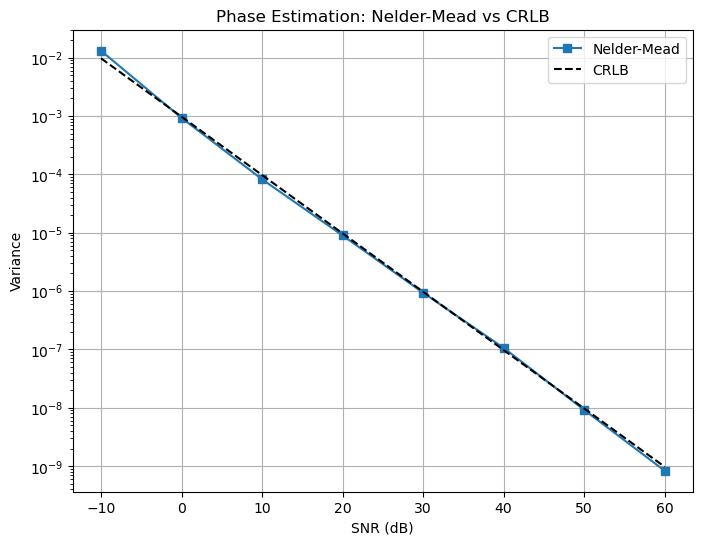

In [20]:
#Oppgave 1b
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ---------- SETUP ----------
Fs = 1e6
T = 1/Fs

f0 = 1e5
w0 = 2*np.pi*f0
phi = np.pi/8
A = 1

N = 513
n = np.arange(-256, 257)

M = 2**10
runs = 50

SNR_values = np.arange(-10, 61, 10)

# ---------- CRLB ----------
def crlb(SNR_dB):
    SNR = 10**(SNR_dB/10)
    sigma2 = 1/(2*SNR)

    n0 = -256
    P = N*(N-1)/2
    Q = N*(N-1)*(2*N-1)/6

    var_freq = (12*sigma2)/(T**2 * N * (N**2 - 1))
    var_phase = (12*sigma2*(n0**2*N + 2*n0*P + Q)) / (N**2 * (N**2 - 1))

    return var_freq, var_phase

# ---------- SIM ----------
def simulate(SNR_dB):
    SNR = 10**(SNR_dB/10)
    sigma2 = 1/(2*SNR)

    err_freq = []
    err_phase = []

    for _ in range(runs):
        noise = (np.random.normal(0, np.sqrt(sigma2), N) +
                 1j*np.random.normal(0, np.sqrt(sigma2), N))

        x = A*np.exp(1j*(w0*n*T + phi)) + noise

        # FFT (start)
        X = np.fft.fft(x, M)
        m = np.argmax(np.abs(X))
        w_fft = 2*np.pi*m/(M*T)

        # Nelder-Mead
        def F(w):
            return -np.abs(np.sum(x*np.exp(-1j*w*n*T))/N)

        w_hat = minimize(F, [w_fft], method='Nelder-Mead').x[0]

        # Phase
        F_hat = np.sum(x*np.exp(-1j*w_hat*n*T))/N
        phi_hat = np.angle(F_hat)

        err_freq.append(w0 - w_hat)
        err_phase.append(phi - phi_hat)

    return np.var(err_freq), np.var(err_phase)

# ---------- KJØR ----------
var_freq = []
var_phase = []
crlb_freq = []
crlb_phase = []

for snr in SNR_values:
    vf, vp = simulate(snr)
    var_freq.append(vf)
    var_phase.append(vp)

    cf, cp = crlb(snr)
    crlb_freq.append(cf)
    crlb_phase.append(cp)

# ---------- PLOT 1: FREKVENS ----------
plt.figure(figsize=(8,6))

plt.semilogy(SNR_values, var_freq, 'o-', label='Nelder-Mead')
plt.semilogy(SNR_values, crlb_freq, 'k--', label='CRLB')

plt.xlabel("SNR (dB)")
plt.ylabel("Variance")
plt.title("Frequency Estimation: Nelder-Mead vs CRLB")
plt.legend()
plt.grid()

plt.show()

# ---------- PLOT 2: FASE ----------
plt.figure(figsize=(8,6))

plt.semilogy(SNR_values, var_phase, 's-', label='Nelder-Mead')
plt.semilogy(SNR_values, crlb_phase, 'k--', label='CRLB')

plt.xlabel("SNR (dB)")
plt.ylabel("Variance")
plt.title("Phase Estimation: Nelder-Mead vs CRLB")
plt.legend()
plt.grid()

plt.show()

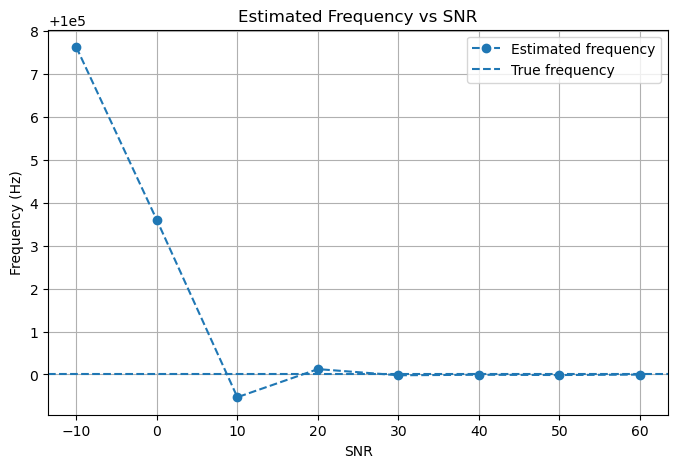

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ---------- SETUP ----------
Fs = 1e6
T = 1/Fs

f0 = 1e5
w0 = 2*np.pi*f0
phi = np.pi/8
A = 1

N = 513
n = np.arange(-256, 257)

M = 2**10
runs = 50

SNR_values = np.arange(-10, 61, 10)

# ---------- SIM ----------
def estimate_mean_freq(SNR_dB):
    SNR = 10**(SNR_dB/10)
    sigma2 = 1/(2*SNR)

    estimates = []

    for _ in range(runs):
        noise = (np.random.normal(0, np.sqrt(sigma2), N) +
                 1j*np.random.normal(0, np.sqrt(sigma2), N))

        x = A*np.exp(1j*(w0*n*T + phi)) + noise

        # FFT
        X = np.fft.fft(x, M)
        m = np.argmax(np.abs(X))
        w_fft = 2*np.pi*m/(M*T)

        # Nelder-Mead refinement
        def F(w):
            return -np.abs(np.sum(x*np.exp(-1j*w*n*T))/N)

        w_hat = minimize(F, [w_fft], method='Nelder-Mead').x[0]

        f_hat = w_hat / (2*np.pi)
        estimates.append(f_hat)

    return np.mean(estimates)

# ---------- KJØR ----------
f_est = []

for snr in SNR_values:
    f_est.append(estimate_mean_freq(snr))

# ---------- PLOT ----------
plt.figure(figsize=(8,5))

plt.plot(SNR_values, f_est, 'o--', label='Estimated frequency')
plt.axhline(f0, linestyle='--', label='True frequency')

plt.xlabel("SNR")
plt.ylabel("Frequency (Hz)")
plt.title("Estimated Frequency vs SNR")
plt.grid()
plt.legend()

plt.show()